# Final Project: Healthcare Data Cleaning

### Aapka Target:
Gender Uniformity: .replace() ya .map() use karke 'M' ko 'Male' aur 'F'/'female' ko 'Female' mein badlein.

Handle Outliers: Blood_Pressure mein jo 400 hai, usay 120 kar dein.

Handle Missing Values: Glucose_Level mein jo NaN hai, usay column ke Median se fill karein.

Remove Duplicates: Patient ID 2 repeat ho raha hai, usay khatam karein.

Challenge: Jab aap ye code likh lein, toh is dafa sirf output ki screenshot nahi, balki code ki screenshot bhi bhejiye ga taake main dekh sakoon ke aapne logic kaise banaya hai.

Iske baad hum seekhenge ke "Portfolio README" kaise likhte hain jo aapke GitHub par client ko impress karega!

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
# Healthcare Project Data 
medical_data = {
    'Patient_ID': [1, 2, 3, 4, 2, 6, 7, 8],
    'Gender': ['Male', 'female', 'M', 'Female', 'female', 'Female', 'Male', 'F'],
    'Blood_Pressure': [120, 130, 400, 115, 130, None, 125, 121], 
    'Glucose_Level': [85, 90, 110, 80, 90, 95, None, 105],
    'Outcome': [0, 1, 0, 0, 1, 1, 0, 1]
}

healthcare_df = pd.DataFrame(medical_data)
print("Healthcare Project Data Loaded! Ab isay clean krna ha.")
healthcare_df

Healthcare Project Data Loaded! Ab isay clean krna ha.


,Patient_ID,Gender,Blood_Pressure,Glucose_Level,Outcome
0,1,Male,120.0,85.0,0
1,2,female,130.0,90.0,1
2,3,M,400.0,110.0,0
3,4,Female,115.0,80.0,0
4,2,female,130.0,90.0,1
5,6,Female,NaN,95.0,1
6,7,Male,125.0,NaN,0
7,8,F,121.0,105.0,1


# Create Messy HealthyCare Data csv

In [48]:
healthcare_df.to_csv('Messy_HealthCare_Data.csv' , index=True)

# Call csv

In [49]:
healthcare_df = pd.read_csv(r'C:\Users\Muhammad Yahya\Downloads\python\Pandas\HealthCare DataCleaning\Messy_HealthCare_Data.csv' , index_col=[0])

In [50]:
healthcare_df.describe()

,Patient_ID,Blood_Pressure,Glucose_Level,Outcome
count,8.000000,7.000000,7.000000,8.000000
mean,4.125000,163.000000,93.571429,0.500000
std,2.587746,104.648618,10.690450,0.534522
min,1.000000,115.000000,80.000000,0.000000
25%,2.000000,120.500000,87.500000,0.000000
50%,3.500000,125.000000,90.000000,0.500000
75%,6.250000,130.000000,100.000000,1.000000
max,8.000000,400.000000,110.000000,1.000000


### STEP:1 
# Gender Uniformly

In [51]:
healthcare_df['Gender'] = healthcare_df['Gender'].replace('F' , 'Female')
healthcare_df

,Patient_ID,Gender,Blood_Pressure,Glucose_Level,Outcome
0,1,Male,120.0,85.0,0
1,2,female,130.0,90.0,1
2,3,M,400.0,110.0,0
3,4,Female,115.0,80.0,0
4,2,female,130.0,90.0,1
5,6,Female,NaN,95.0,1
6,7,Male,125.0,NaN,0
7,8,Female,121.0,105.0,1


In [52]:
healthcare_df['Gender'] = healthcare_df['Gender'].replace('M' , 'Male')
healthcare_df

,Patient_ID,Gender,Blood_Pressure,Glucose_Level,Outcome
0,1,Male,120.0,85.0,0
1,2,female,130.0,90.0,1
2,3,Male,400.0,110.0,0
3,4,Female,115.0,80.0,0
4,2,female,130.0,90.0,1
5,6,Female,NaN,95.0,1
6,7,Male,125.0,NaN,0
7,8,Female,121.0,105.0,1


### STEP:2
# Handle Outlier From (Blood Pressure) Feature 


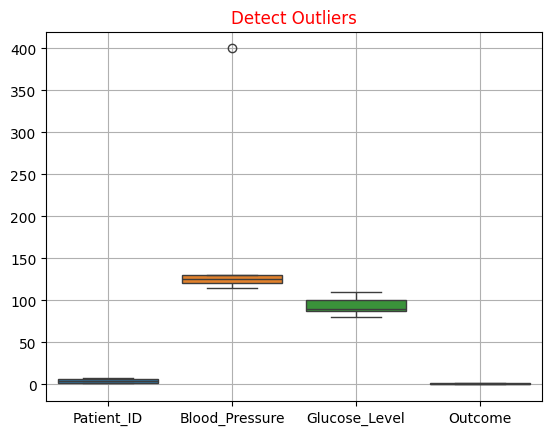

In [53]:
sns.boxplot(healthcare_df)
plt.title('Detect Outliers' , color='r')
plt.grid()
plt.show()

In [54]:
healthcare_df['Blood_Pressure'].describe()

count      7.000000
mean     163.000000
std      104.648618
min      115.000000
25%      120.500000
50%      125.000000
75%      130.000000
max      400.000000
Name: Blood_Pressure, dtype: float64

In [55]:
for maxi in healthcare_df['Blood_Pressure']:

    if maxi >= 200:
        print(f'Outlier={maxi}')  #Confirm this is outlier

        if maxi == 400:

            maxi = 120
            print(f'Outlier Handle:{maxi}\n')

            healthcare_df.loc[2 , 'Blood_Pressure'] = maxi
            print(f'----------After Handling Outlier:----------\n{healthcare_df}')       

Outlier=400.0
Outlier Handle:120

----------After Handling Outlier:----------
   Patient_ID  Gender  Blood_Pressure  Glucose_Level  Outcome
0           1    Male           120.0           85.0        0
1           2  female           130.0           90.0        1
2           3    Male           120.0          110.0        0
3           4  Female           115.0           80.0        0
4           2  female           130.0           90.0        1
5           6  Female             NaN           95.0        1
6           7    Male           125.0            NaN        0
7           8  Female           121.0          105.0        1


### STEP:3
# Handle Missing Value From (Blood Pressure) Feature

In [56]:
healthcare_df.loc[5 , 'Blood_Pressure'] = healthcare_df['Blood_Pressure'].mean()
healthcare_df

,Patient_ID,Gender,Blood_Pressure,Glucose_Level,Outcome
0,1,Male,120.0,85.0,0
1,2,female,130.0,90.0,1
2,3,Male,120.0,110.0,0
3,4,Female,115.0,80.0,0
4,2,female,130.0,90.0,1
5,6,Female,123.0,95.0,1
6,7,Male,125.0,NaN,0
7,8,Female,121.0,105.0,1


In [57]:
healthcare_df.describe()

,Patient_ID,Blood_Pressure,Glucose_Level,Outcome
count,8.000000,8.000000,7.000000,8.000000
mean,4.125000,123.000000,93.571429,0.500000
std,2.587746,5.182388,10.690450,0.534522
min,1.000000,115.000000,80.000000,0.000000
25%,2.000000,120.000000,87.500000,0.000000
50%,3.500000,122.000000,90.000000,0.500000
75%,6.250000,126.250000,100.000000,1.000000
max,8.000000,130.000000,110.000000,1.000000


### STEP:4 
# Handle Missing Value From (Glucose_Leve) Features
Value must fill use median 

In [58]:
# Check Index Missing Value 
healthcare_df['Glucose_Level'].isnull()

0    False
1    False
2    False
3    False
4    False
5    False
6     True
7    False
Name: Glucose_Level, dtype: bool

In [59]:
healthcare_df.loc[6 , 'Glucose_Level'] = healthcare_df['Glucose_Level'].median()
healthcare_df

,Patient_ID,Gender,Blood_Pressure,Glucose_Level,Outcome
0,1,Male,120.0,85.0,0
1,2,female,130.0,90.0,1
2,3,Male,120.0,110.0,0
3,4,Female,115.0,80.0,0
4,2,female,130.0,90.0,1
5,6,Female,123.0,95.0,1
6,7,Male,125.0,90.0,0
7,8,Female,121.0,105.0,1


In [60]:
healthcare_df.describe()

,Patient_ID,Blood_Pressure,Glucose_Level,Outcome
count,8.000000,8.000000,8.000000,8.000000
mean,4.125000,123.000000,93.125000,0.500000
std,2.587746,5.182388,9.977654,0.534522
min,1.000000,115.000000,80.000000,0.000000
25%,2.000000,120.000000,88.750000,0.000000
50%,3.500000,122.000000,90.000000,0.500000
75%,6.250000,126.250000,97.500000,1.000000
max,8.000000,130.000000,110.000000,1.000000


### STEP:5
# Remove Duplicate Values FROM (Patient ID) Feature

In [61]:
healthcare_df['Patient_ID'].duplicated()

0    False
1    False
2    False
3    False
4     True
5    False
6    False
7    False
Name: Patient_ID, dtype: bool

In [62]:
healthcare_df.loc[4 , 'Patient_ID'] = 5
healthcare_df

,Patient_ID,Gender,Blood_Pressure,Glucose_Level,Outcome
0,1,Male,120.0,85.0,0
1,2,female,130.0,90.0,1
2,3,Male,120.0,110.0,0
3,4,Female,115.0,80.0,0
4,5,female,130.0,90.0,1
5,6,Female,123.0,95.0,1
6,7,Male,125.0,90.0,0
7,8,Female,121.0,105.0,1


In [63]:
healthcare_df.describe() #Statistical Summary

,Patient_ID,Blood_Pressure,Glucose_Level,Outcome
count,8.00000,8.000000,8.000000,8.000000
mean,4.50000,123.000000,93.125000,0.500000
std,2.44949,5.182388,9.977654,0.534522
min,1.00000,115.000000,80.000000,0.000000
25%,2.75000,120.000000,88.750000,0.000000
50%,4.50000,122.000000,90.000000,0.500000
75%,6.25000,126.250000,97.500000,1.000000
max,8.00000,130.000000,110.000000,1.000000


In [64]:
healthcare_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient_ID      8 non-null      int64  
 1   Gender          8 non-null      object 
 2   Blood_Pressure  8 non-null      float64
 3   Glucose_Level   8 non-null      float64
 4   Outcome         8 non-null      int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 684.0+ bytes


In [65]:
healthcare_df.duplicated()

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
dtype: bool

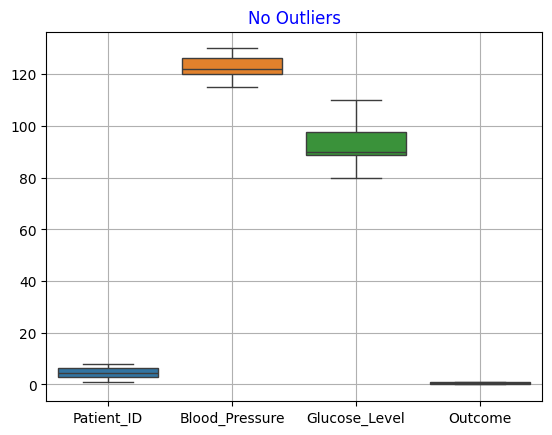

In [66]:
sns.boxplot(healthcare_df)
plt.title('No Outliers' , color='blue')
plt.grid()
plt.show()

### After Cleaning HealthCare Data
# Create csv

In [67]:
healthcare_df.to_csv('Clean_HealthCare.csv' , index=True)